# One-Loop Power Spectra with `clax.ept`

Reproduces the plots from the CLASS-PT `nonlinear_pt.ipynb` notebook
using `clax.ept` (JAX-native, differentiable EFTofLSS one-loop power spectra).

In [1]:
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import clax
from clax.ept import (
    EPTPrecisionParams, compute_ept, ept_kgrid,
    pk_mm_real, pk_gm_real, pk_gg_real,
    pk_mm_l0, pk_mm_l2, pk_mm_l4,
    pk_gg_l0, pk_gg_l2, pk_gg_l4,
    compute_ept_from_clax,
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "STIXGeneral",
    "font.sans-serif": "Computer Modern",
    "font.size": 24,
    "axes.linewidth": 1.5,
    "legend.frameon": False,

    **{f"{axis}tick.direction": "in" for axis in "xy"},
    **{f"{axis}tick.major.size": 6.0 for axis in "xy"},
    **{f"{axis}tick.major.width": 1.0 for axis in "xy"},
    **{f"{axis}tick.minor.size": 4.0 for axis in "xy"},
    **{f"{axis}tick.minor.width": 0.8 for axis in "xy"},
    **{f"{axis}tick.minor.visible": True for axis in "xy"},

    "xtick.top": True,
    "ytick.right": True,
})

## 1. Cosmology and Pipeline Setup

Same cosmological parameters as the CLASS-PT notebook (Planck 2018 best-fit with one massive neutrino).

In [2]:
z_pk = 0.61

# Cosmological parameters matching CLASS-PT notebook
params = clax.CosmoParams(
    h=0.6736,
    omega_b=0.02237,
    omega_cdm=0.12,
    ln10A_s=np.log(2.089e-9 * 1e10),  # A_s = 2.089e-9
    n_s=0.9649,
    tau_reio=0.052,
    # Neutrinos: N_ur=2.0328, 1 massive with m=0.06 eV
)

# Use Rodas5 (Rosenbrock) solver for ~3-5x faster perturbation ODE
from dataclasses import replace as dc_replace
prec = dc_replace(clax.PrecisionParams(), pt_ode_solver="rodas5")

# Run the clax pipeline: background + thermodynamics
bg = clax.background_solve(params, prec)
th = clax.thermodynamics_solve(params, prec, bg)

h = float(params.h)
print(f"h = {h}")
print(f"Omega_m = {bg.Omega_b + bg.Omega_cdm + bg.Omega_ncdm:.5f}")

h = 0.6736
Omega_m = 0.31519


## 2. Compute EPT One-Loop Spectra

Compute the linear P(k) at z=0.61 and run the EPT pipeline with and without IR resummation.

In [3]:
# EPT k-grid
ept_prec = EPTPrecisionParams(ir_resummation=True)
ept_prec_noir = EPTPrecisionParams(ir_resummation=False)
k_h = ept_kgrid(ept_prec)  # h/Mpc
k_mpc = k_h * h              # Mpc^-1

# Solve for P_lin on the default k-grid (up to ~5 Mpc^-1), then
# spline-extrapolate to the full EPT range.  The perturbation ODE is
# very expensive at k >> 1 Mpc^-1, but P_lin there is a smooth power-law
# (transfer function ~ ln(k)/k^2), so extrapolation is accurate.
pk_table = clax.compute_pk_table(params, prec, z=z_pk)

from scipy.interpolate import InterpolatedUnivariateSpline
k_solve = np.array(pk_table.solve_k_grid)
pk_solve = np.array(pk_table.pk(k_solve, z=z_pk))  # Mpc^3

# Spline in log-log space (handles the smooth power-law tail)
mask = pk_solve > 0
log_spl = InterpolatedUnivariateSpline(
    np.log(k_solve[mask]), np.log(pk_solve[mask]), k=3)
pk_lin_mpc = np.exp(log_spl(np.log(k_mpc)))
pk_lin_h = pk_lin_mpc * h**3  # (Mpc/h)^3

# Growth rate f from background spline
loga_z = float(jnp.log(1.0 / (1.0 + z_pk)))
f_z = float(bg.f_of_loga.evaluate(jnp.atleast_1d(loga_z))[0])
print(f"f(z={z_pk}) = {f_z:.4f}")

# Compute EPT with and without IR resummation
ept_ir = compute_ept(jnp.array(pk_lin_h), jnp.array(k_h), h=h, f=f_z, prec=ept_prec)
ept_noir = compute_ept(jnp.array(pk_lin_h), jnp.array(k_h), h=h, f=f_z, prec=ept_prec_noir)

# k-vector for plotting (h/Mpc)
kvec = np.array(k_h)

print("EPT computation complete.")
print(f"  k range: [{kvec[0]:.1e}, {kvec[-1]:.1e}] h/Mpc")
print(f"  N_k = {len(kvec)}")
print(f"  Perturbation solve range: [{k_solve[0]:.1e}, {k_solve[-1]:.2f}] Mpc^-1 ({len(k_solve)} modes)")
print(f"  Extrapolated to {float(k_mpc[-1]):.1f} Mpc^-1 via log-log spline")

f(z=0.61) = 0.7923
EPT computation complete.
  k range: [5.0e-05, 1.0e+02] h/Mpc
  N_k = 256
  Perturbation solve range: [1.0e-05, 5.00] Mpc^-1 (170 modes)
  Extrapolated to 67.4 Mpc^-1 via log-log spline


In [4]:
# Nuisance parameters (same as CLASS-PT notebook)
b1 = 2.0
cs = 1.0        # (Mpc/h)^2
b2 = -1.0
bG2 = 0.1
bGamma3 = -0.1
Pshot = 5e3     # (Mpc/h)^3
cs0 = 5.0       # (Mpc/h)^2
cs2 = 15.0      # (Mpc/h)^2
cs4 = -5.0      # (Mpc/h)^2
b4 = 100.0      # (Mpc/h)^4

# Compute assembled spectra from EPT components (IR-resummed)
pk_mm_full_ir = np.array(pk_mm_real(ept_ir, cs))
pk_gg = np.array(pk_gg_real(ept_ir, b1, b2, bG2, bGamma3, cs, cs0, Pshot))
pk_gm = np.array(pk_gm_real(ept_ir, b1, b2, bG2, bGamma3, cs, cs0))

# Without IR resummation
pk_mm_full = np.array(pk_mm_real(ept_noir, cs))

# RSD matter multipoles
pk_m0 = np.array(pk_mm_l0(ept_ir, cs0))
pk_m2 = np.array(pk_mm_l2(ept_ir, cs2))
pk_m4 = np.array(pk_mm_l4(ept_ir, cs4))

# RSD galaxy multipoles
pk_g0 = np.array(pk_gg_l0(ept_ir, b1, b2, bG2, bGamma3, cs0, Pshot, b4))
pk_g2 = np.array(pk_gg_l2(ept_ir, b1, b2, bG2, bGamma3, cs2, b4))
pk_g4 = np.array(pk_gg_l4(ept_ir, b1, b2, bG2, bGamma3, cs4, b4))

# Individual components
pk_tree = np.array(ept_noir.Pk_tree)
pk_loop = np.array(ept_noir.Pk_loop)
pk_ctr = 2.0 * cs * np.array(ept_noir.Pk_ctr)

print("All spectra computed.")

All spectra computed.


## 3. Real-Space Matter Power Spectrum (Plot 1)

Decomposition into tree-level (linear), 1-loop, and counterterm contributions.

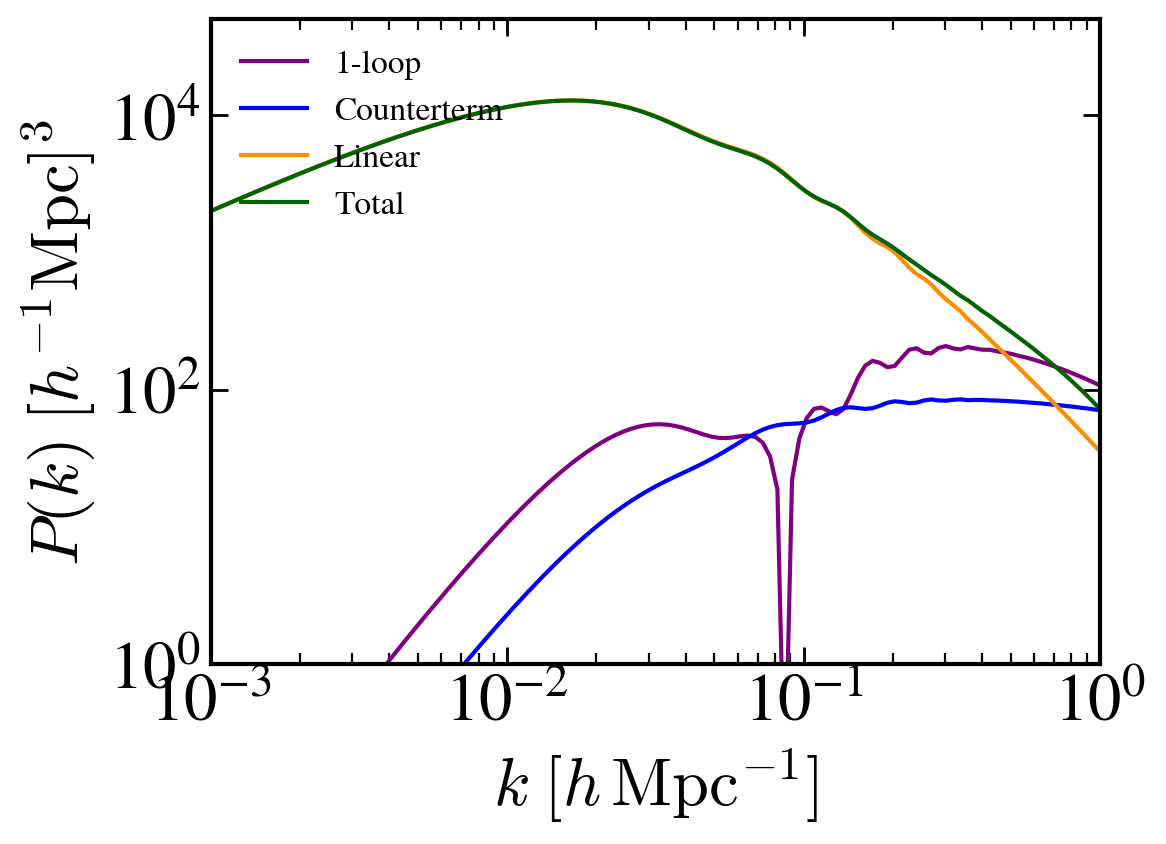

In [5]:
fig, ax = plt.subplots()
ax.loglog(kvec, np.abs(pk_loop), color='purple', ls='-', label='1-loop')
ax.loglog(kvec, np.abs(pk_ctr), color='b', ls='-', label='Counterterm')
ax.loglog(kvec, pk_tree, color='darkorange', ls='-', label='Linear')
ax.loglog(kvec, pk_mm_full, color='darkgreen', ls='-', label='Total')
ax.set_xlim(1e-3, 1)
ax.set_ylim(1, 5e4)
ax.set_xlabel(r'$k \; [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) \; [h^{-1}\mathrm{Mpc}]^3$')
ax.legend(fontsize=12, loc='upper left')
fig.tight_layout()
fig.savefig('figures/real_Pk.pdf')

## 4. IR Resummation Effect (Plot 2)

BAO wiggles are damped by the IR resummation, matching the observed broadening of the BAO peak.

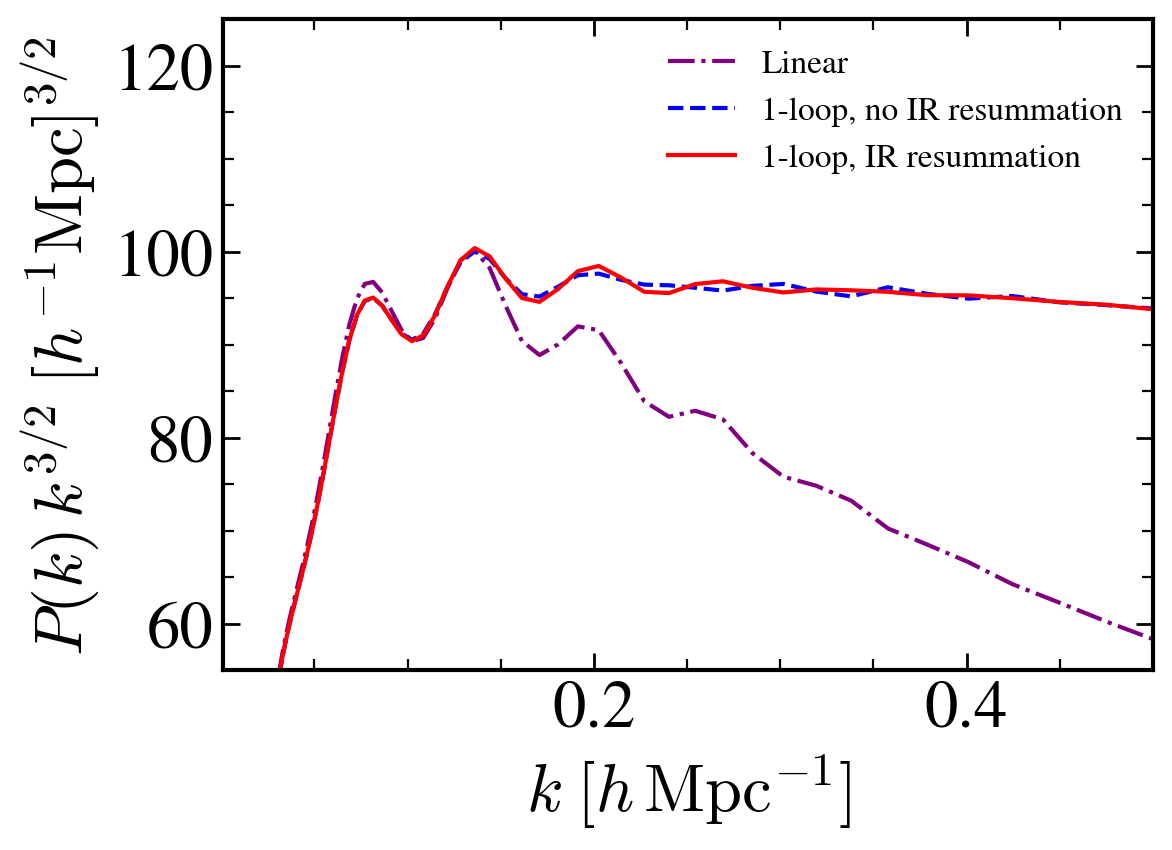

In [6]:
fig, ax = plt.subplots()
ax.plot(kvec, pk_lin_h * kvec**1.5, color='purple', ls='-.', label='Linear')
ax.plot(kvec, pk_mm_full * kvec**1.5, color='b', ls='--', label='1-loop, no IR resummation')
ax.plot(kvec, pk_mm_full_ir * kvec**1.5, color='r', ls='-', label='1-loop, IR resummation')
ax.set_xlim(1e-3, 0.5)
ax.set_ylim(55, 125)
ax.set_xlabel(r'$k \; [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\,k^{3/2} \; [h^{-1}\mathrm{Mpc}]^{3/2}$')
ax.legend(fontsize=12, loc='upper right')
fig.tight_layout()
fig.savefig('figures/real_Pk_IR.pdf')

## 5. Real-Space Galaxy and Cross Spectra (Plot 3)

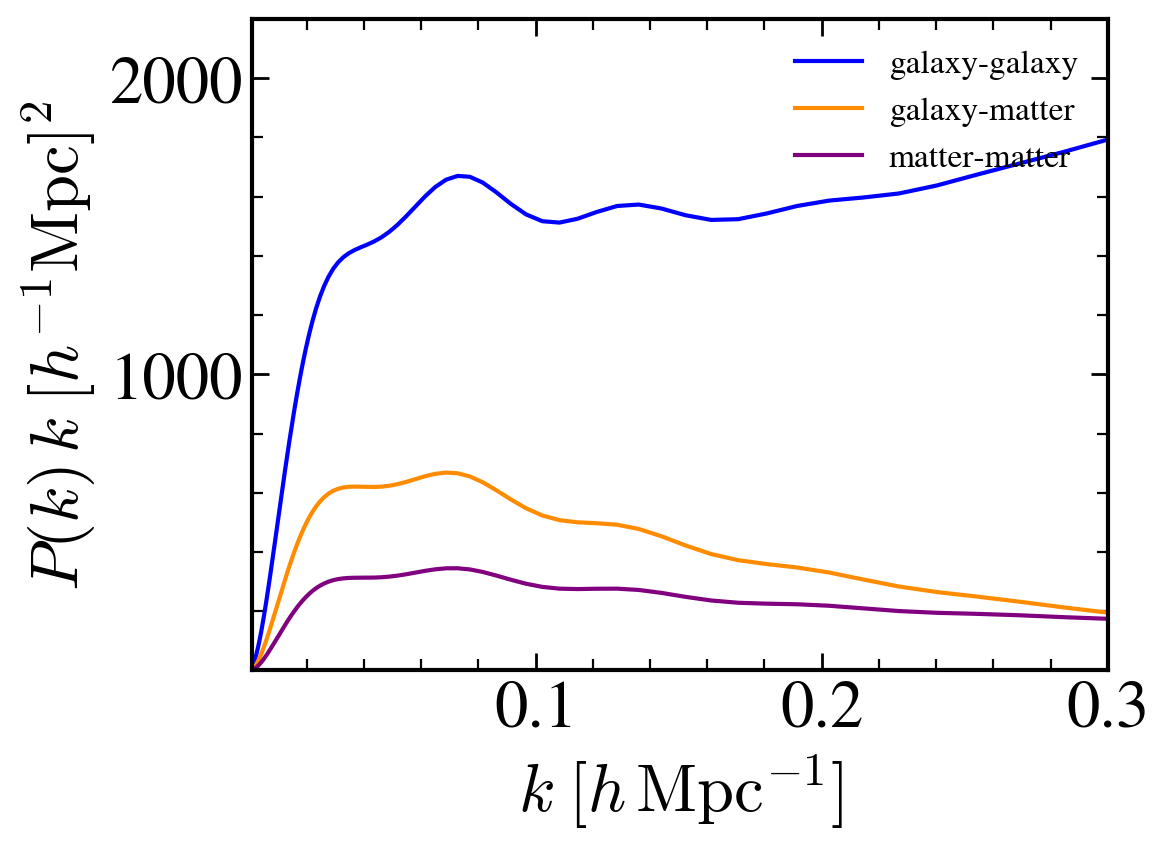

In [7]:
fig, ax = plt.subplots()
ax.plot(kvec, pk_gg * kvec, color='b', ls='-', label='galaxy-galaxy')
ax.plot(kvec, pk_gm * kvec, color='darkorange', ls='-', label='galaxy-matter')
ax.plot(kvec, pk_mm_full_ir * kvec, color='purple', ls='-', label='matter-matter')
ax.set_xlim(1e-3, 0.3)
ax.set_ylim(1, 2200)
ax.set_xlabel(r'$k \; [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\,k \; [h^{-1}\mathrm{Mpc}]^{2}$')
ax.legend(fontsize=12, loc='upper right')
fig.tight_layout()
fig.savefig('figures/real_Pkgg.pdf')

## 6. Bias Spectrum Components (Plot 4)

Individual loop integral contributions to the biased tracer power spectrum.

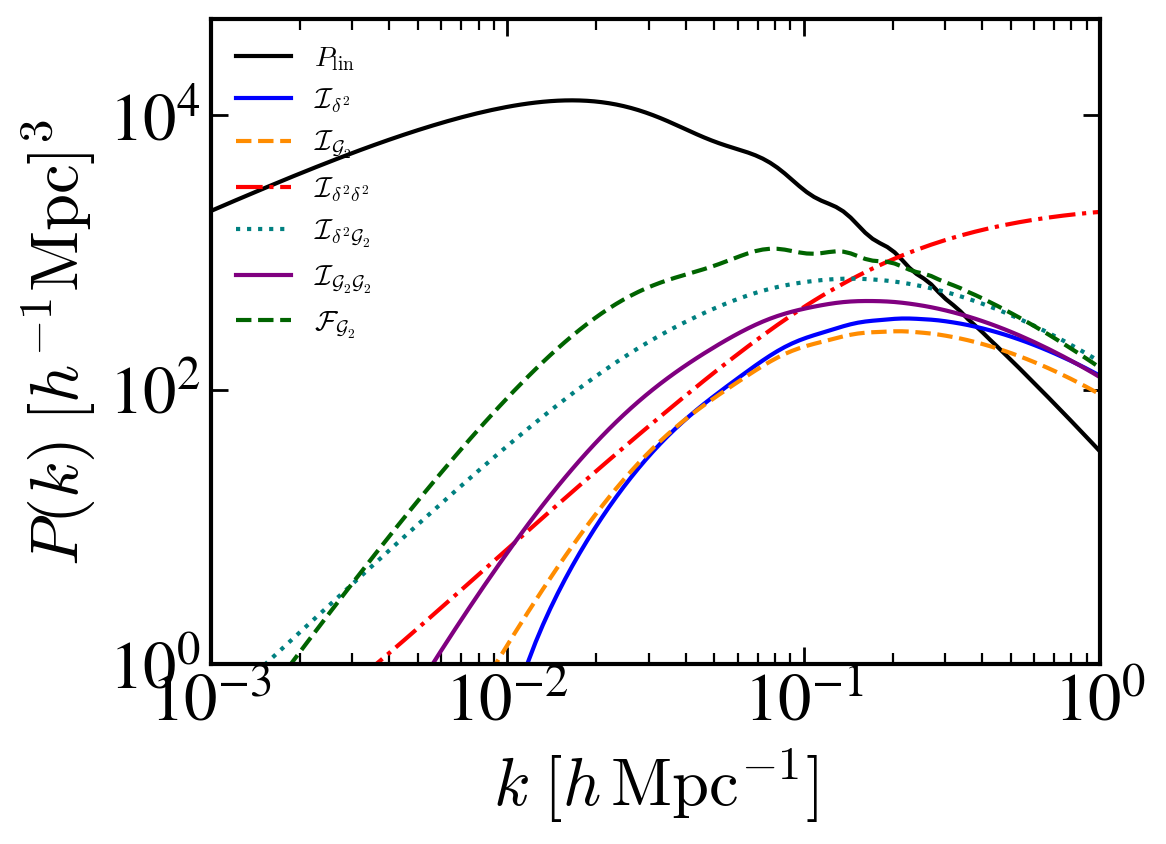

In [8]:
# Extract bias cross-spectra from the IR-resummed EPT result
pk_Id2 = np.array(ept_ir.Pk_Id2)
pk_IG2 = np.array(ept_ir.Pk_IG2)
pk_Id2d2 = np.array(ept_ir.Pk_Id2d2)
pk_Id2G2 = np.array(ept_ir.Pk_Id2G2)
pk_IG2G2 = np.array(ept_ir.Pk_IG2G2)
pk_IFG2 = np.array(ept_ir.Pk_IFG2)

fig, ax = plt.subplots()
ax.loglog(kvec, pk_lin_h, color='k', ls='-', label=r'$P_{\rm lin}$')
ax.loglog(kvec, np.abs(pk_Id2), color='b', ls='-', label=r'$\mathcal{I}_{\delta^2}$')
ax.loglog(kvec, np.abs(pk_IG2), color='darkorange', ls='--', label=r'$\mathcal{I}_{\mathcal{G}_2}$')
ax.loglog(kvec, np.abs(pk_Id2d2), color='r', ls='-.', label=r'$\mathcal{I}_{\delta^2\delta^2}$')
ax.loglog(kvec, np.abs(pk_Id2G2), color='teal', ls=':', label=r'$\mathcal{I}_{\delta^2\mathcal{G}_2}$')
ax.loglog(kvec, np.abs(pk_IG2G2), color='purple', ls='-', label=r'$\mathcal{I}_{\mathcal{G}_2\mathcal{G}_2}$')
ax.loglog(kvec, np.abs(pk_IFG2), color='darkgreen', ls='--', label=r'$\mathcal{F}_{\mathcal{G}_2}$')
ax.set_xlim(1e-3, 1)
ax.set_ylim(1, 5e4)
ax.set_xlabel(r'$k \; [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) \; [h^{-1}\mathrm{Mpc}]^3$')
ax.legend(fontsize=10, loc='upper left')
fig.tight_layout()
fig.savefig('figures/real_Pkgg_breakdown.pdf')

## 7. Redshift-Space Matter Multipoles (Plot 5)

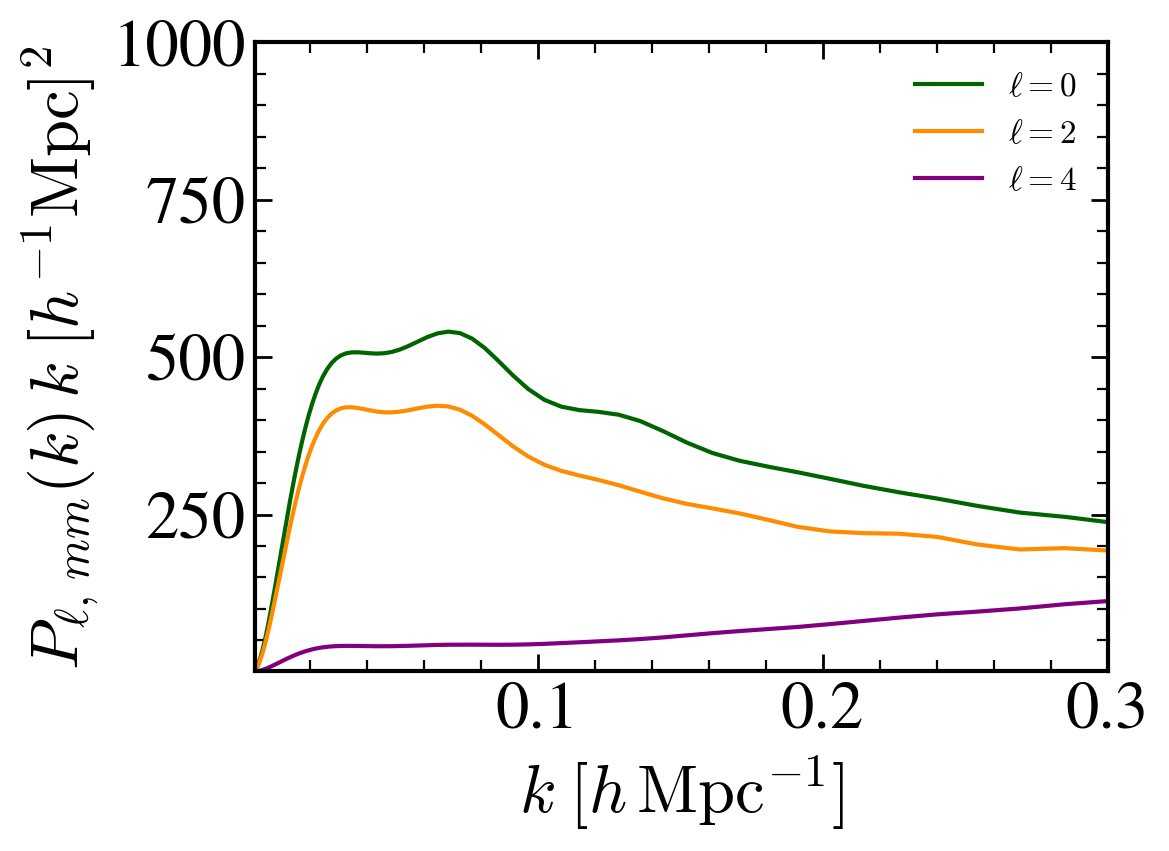

In [9]:
fig, ax = plt.subplots()
ax.plot(kvec, pk_m0 * kvec, color='darkgreen', ls='-', label=r'$\ell = 0$')
ax.plot(kvec, pk_m2 * kvec, color='darkorange', ls='-', label=r'$\ell = 2$')
ax.plot(kvec, pk_m4 * kvec, color='purple', ls='-', label=r'$\ell = 4$')
ax.set_xlim(1e-3, 0.3)
ax.set_ylim(1, 1000)
ax.set_xlabel(r'$k \; [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\ell,\,mm}(k)\,k \; [h^{-1}\mathrm{Mpc}]^{2}$')
ax.legend(fontsize=12, loc='upper right')
fig.tight_layout()
fig.savefig('figures/rsd_Pkmm.pdf')

## 8. Redshift-Space Galaxy Multipoles (Plot 6)

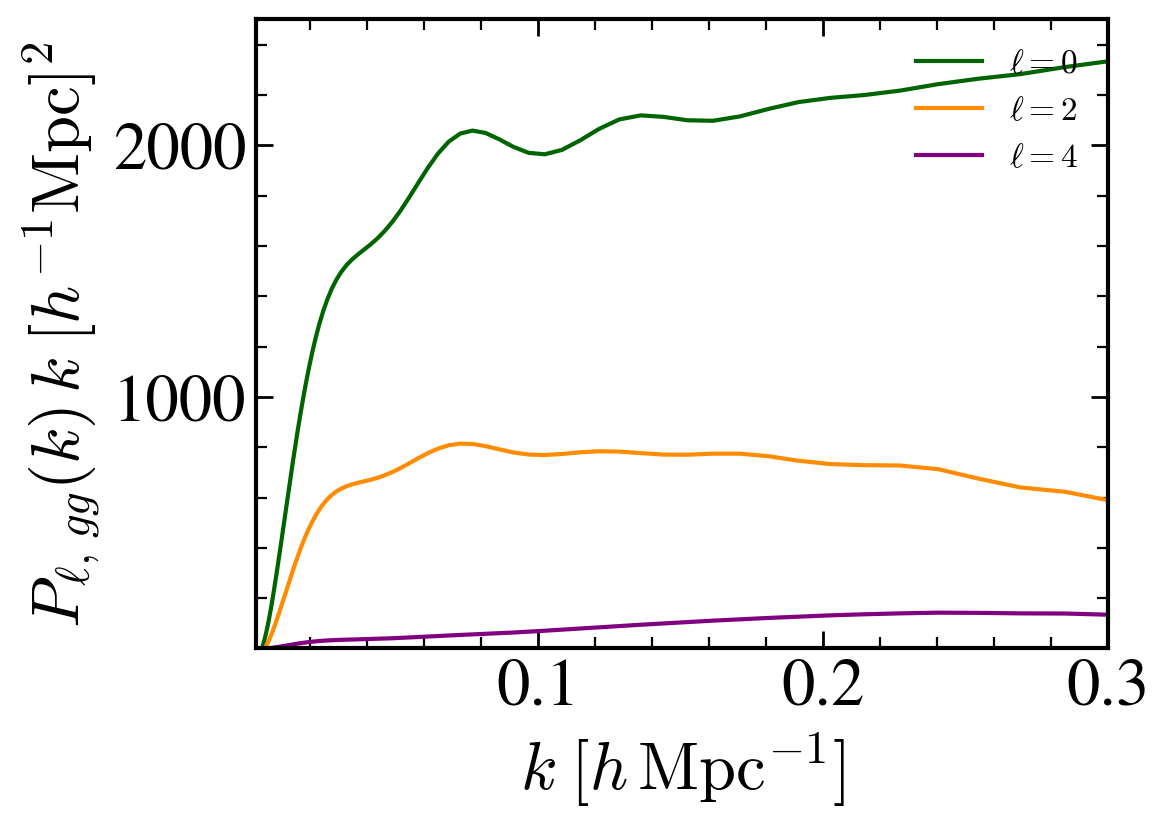

In [10]:
fig, ax = plt.subplots()
ax.plot(kvec, pk_g0 * kvec, color='darkgreen', ls='-', label=r'$\ell = 0$')
ax.plot(kvec, pk_g2 * kvec, color='darkorange', ls='-', label=r'$\ell = 2$')
ax.plot(kvec, pk_g4 * kvec, color='purple', ls='-', label=r'$\ell = 4$')
ax.set_xlim(1e-3, 0.3)
ax.set_ylim(1, 2500)
ax.set_xlabel(r'$k \; [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\ell,\,gg}(k)\,k \; [h^{-1}\mathrm{Mpc}]^{2}$')
ax.legend(fontsize=12, loc='upper right')
fig.tight_layout()
fig.savefig('figures/rsd_Pkgg.pdf')

## 9. Position-Space Correlation Function (Plot 7)

Fourier transform P(k) to xi(r) using FFTLog, comparing linear, 1-loop without IR resummation, and 1-loop with IR resummation.

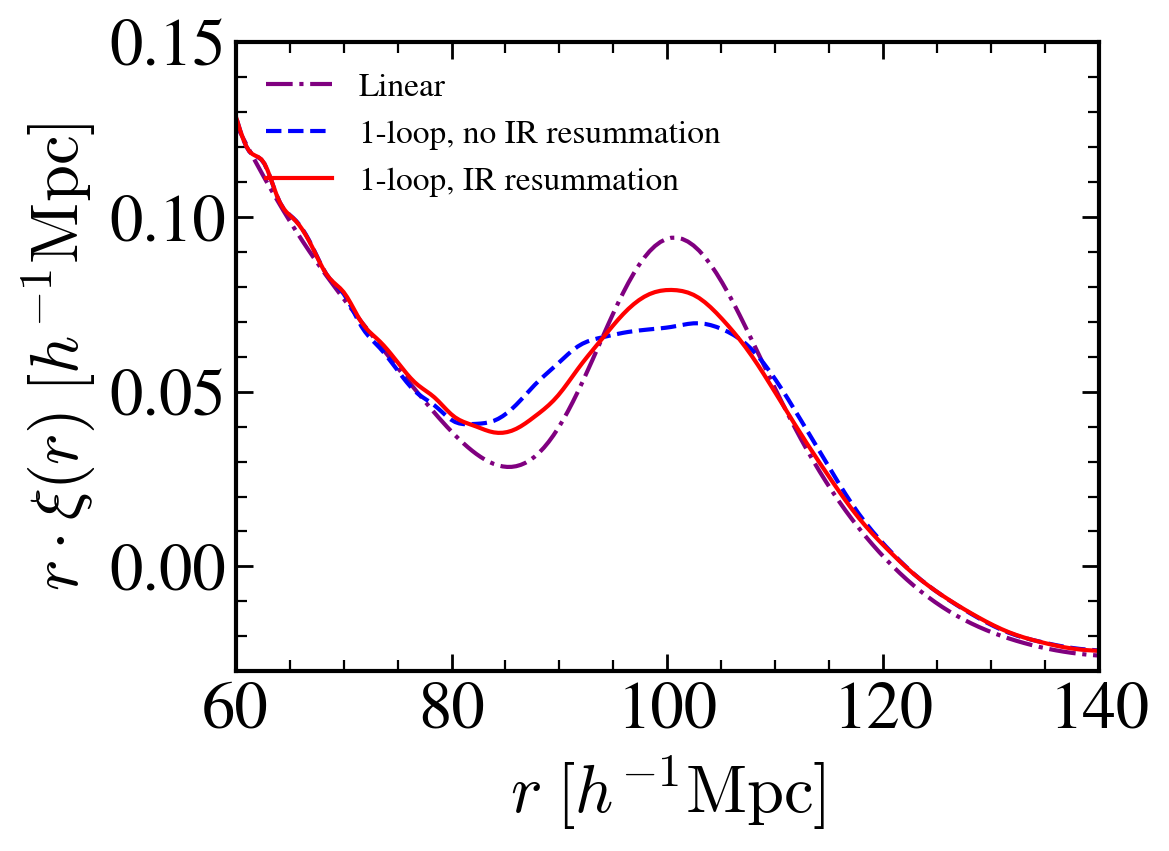

In [11]:
from scipy.special import gamma as sp_gamma
from scipy.interpolate import InterpolatedUnivariateSpline

def pk_to_xi(kvec_h, pk_h, Nmax=512, kmin=1e-4, kmax=100.0,
             rmin=0.01, rmax=1000.0, bk=-1.1001):
    """Convert P(k) to xi(r) via FFTLog (Hankel transform).

    Uses the same algorithm as the CLASS-PT notebook.
    """
    Delta = np.log(kmax / kmin) / (Nmax - 1)
    Delta_r = np.log(rmax / rmin) / (Nmax - 1)

    kbins = kmin * np.exp(Delta * np.arange(Nmax))
    rtab = rmin * np.exp(Delta_r * np.arange(Nmax))

    # Interpolate P(k) to the FFTLog k-grid
    pk_interp = InterpolatedUnivariateSpline(np.log(kvec_h), np.log(np.abs(pk_h) + 1e-30))
    pk_fftlog = np.sign(np.interp(kbins, kvec_h, pk_h)) * np.exp(pk_interp(np.log(kbins)))

    # Discretize with bias and UV cutoff
    Pdiscrin = pk_fftlog * np.exp(-(kbins / 4.0)**4 - bk * np.arange(Nmax) * Delta)

    # FFT and symmetrize
    cm = np.fft.fft(Pdiscrin) / Nmax
    jsNm = np.arange(-Nmax // 2, Nmax // 2 + 1, 1)
    etam = bk + 2j * np.pi * jsNm / Nmax / Delta

    cmsym = np.zeros(Nmax + 1, dtype=complex)
    for i in range(Nmax + 1):
        if (i + 2 - Nmax // 2) < 1:
            cmsym[i] = kmin**(-etam[i]) * np.conj(cm[-i + Nmax // 2])
        else:
            cmsym[i] = kmin**(-etam[i]) * cm[i - Nmax // 2]
    cmsym[0] /= 2
    cmsym[-1] /= 2

    # Kernel J_0(r, nu) for spherical Bessel j_0
    def J0(r, nu):
        return -np.sin(np.pi * nu / 2) * r**(-3 - nu) * sp_gamma(2 + nu) / (2 * np.pi**2)

    # Sum over modes
    xi = np.zeros(Nmax)
    for i in range(Nmax):
        for j in range(Nmax + 1):
            xi[i] += np.real(cmsym[j] * J0(rtab[i], etam[j]))

    return rtab, xi

# Compute xi(r) for three cases
rtab, xi_lin = pk_to_xi(kvec, pk_lin_h)
_, xi_loop = pk_to_xi(kvec, pk_mm_full)
_, xi_loop_ir = pk_to_xi(kvec, pk_mm_full_ir)

# Interpolate to plotting grid
rvec = np.logspace(0, np.log10(3), 1000)
rvec = 10**rvec

xi_lin_interp = InterpolatedUnivariateSpline(rtab, xi_lin)
xi_loop_interp = InterpolatedUnivariateSpline(rtab, xi_loop)
xi_loop_ir_interp = InterpolatedUnivariateSpline(rtab, xi_loop_ir)

fig, ax = plt.subplots()
ax.plot(rvec, xi_lin_interp(rvec) * rvec, color='purple', ls='-.', label='Linear')
ax.plot(rvec, xi_loop_interp(rvec) * rvec, color='b', ls='--', label='1-loop, no IR resummation')
ax.plot(rvec, xi_loop_ir_interp(rvec) * rvec, color='red', ls='-', label='1-loop, IR resummation')
ax.set_xlim(60, 140)
ax.set_ylim(-0.03, 0.15)
ax.set_xlabel(r'$r \; [h^{-1}\mathrm{Mpc}]$')
ax.set_ylabel(r'$r \cdot \xi(r) \; [h^{-1}\mathrm{Mpc}]$')
ax.legend(fontsize=12, loc='upper left')
fig.tight_layout()
fig.savefig('figures/real_Xi.pdf')

## 10. External Linear Power Spectrum (Plot 10)

Demonstrates using an arbitrary external P_lin(k) as input to `compute_ept`.

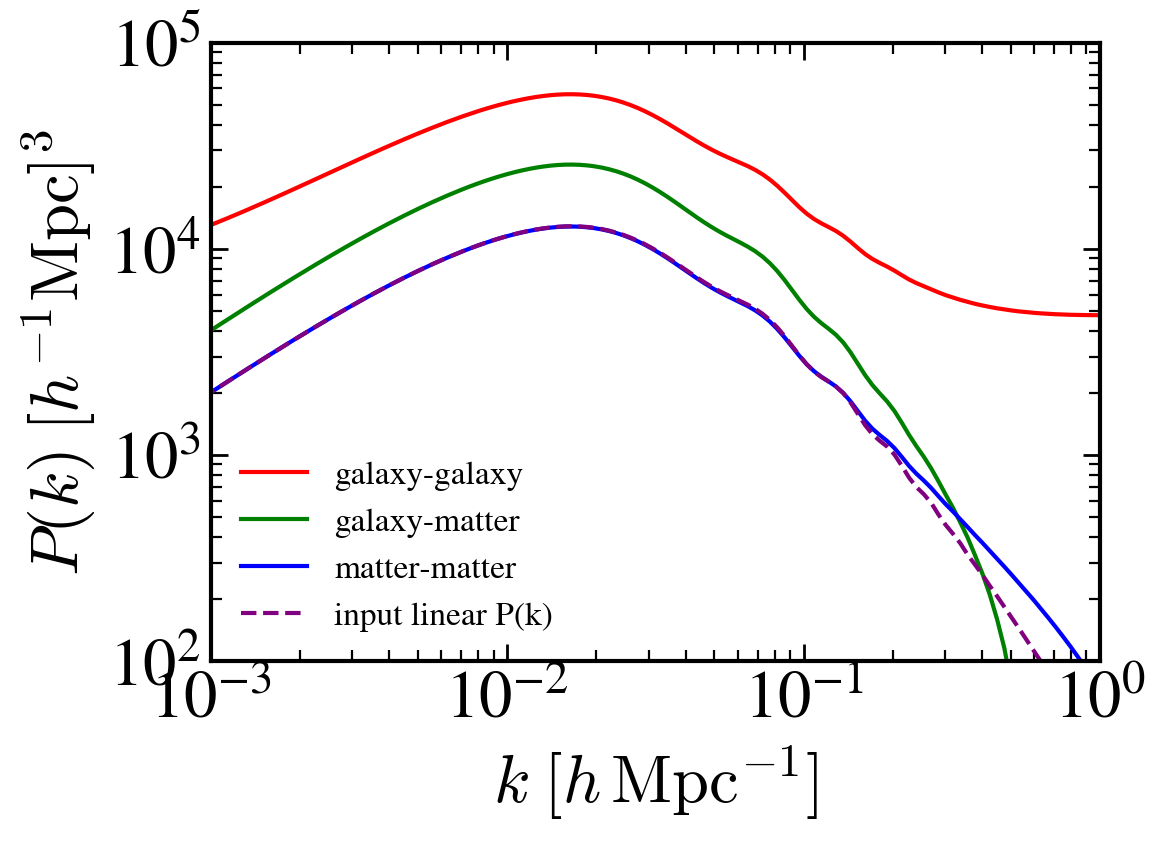

In [12]:
# The EPT computation already used an "external" P_lin via compute_pk_table.
# Here we show this explicitly: any P_lin(k) array can be fed to compute_ept.

# Reuse the same pk_lin_h from above as the "external" input
ept_ext = compute_ept(jnp.array(pk_lin_h), jnp.array(k_h), h=h, f=f_z, prec=ept_prec)

pk_gg_ext = np.array(pk_gg_real(ept_ext, b1, b2, bG2, bGamma3, cs, cs0, Pshot))
pk_gm_ext = np.array(pk_gm_real(ept_ext, b1, b2, bG2, bGamma3, cs, cs0))
pk_mm_ext = np.array(pk_mm_real(ept_ext, cs))

fig, ax = plt.subplots()
ax.loglog(kvec, pk_gg_ext, color='r', ls='-', label='galaxy-galaxy')
ax.loglog(kvec, pk_gm_ext, color='g', ls='-', label='galaxy-matter')
ax.loglog(kvec, pk_mm_ext, color='b', ls='-', label='matter-matter')
ax.loglog(kvec, pk_lin_h, color='purple', ls='--', label='input linear P(k)')
ax.set_xlim(1e-3, 1)
ax.set_ylim(100, 1e5)
ax.set_xlabel(r'$k \; [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) \; [h^{-1}\mathrm{Mpc}]^3$')
ax.legend(fontsize=12, loc='lower left')
fig.tight_layout()
fig.savefig('figures/external_Pk.pdf')

## 11. CMB Lensing: Nonlinear Corrections (Plots 8-9)

Compute the lensing potential $C_\ell^{\phi\phi}$ and lensed TT power spectrum,
comparing linear, Halofit, and 1-loop PT corrections.

- **Linear $C_\ell^{\phi\phi}$**: `compute_cl_pp_source_limber` (source-based Limber, $<1\%$ vs CLASS at all $\ell \leq 2500$)
- **Halofit $C_\ell^{\phi\phi}$**: `compute_cl_pp_limber(nonlinear=True)` (Poisson-based Limber + Halofit $P(k)$)
- **1-loop PT $C_\ell^{\phi\phi}$**: derived by applying CLASS-PT NL/linear ratio to our linear $C_\ell^{\phi\phi}$

Reference data: CLASS v3.3.4 (`classpt_clpp_halofit.npz`) and CLASS-PT (`classpt_clpp_1loop.npz`).

**Note on discrepancy with CLASS-PT notebook:**
Our NL/linear ratios are significantly larger than those shown in the original
[CLASS-PT `nonlinear_pt.ipynb`](https://github.com/Michalychforever/CLASS-PT/blob/master/notebooks/nonlinear_pt.ipynb)
(e.g., $C_\ell^{\phi\phi}$ Halofit/linear $\approx 1.7$ at $\ell = 2500$ vs $\approx 1.2$ in the old CLASS-PT).
This is because the default CLASS-PT (based on CLASS v2.x) uses
`k_max_tau0_over_l_max = 1.8`, which limits the Limber $k$-grid to
$k_\mathrm{max} \approx 0.3\;\mathrm{Mpc}^{-1}$.  At $\ell \gtrsim 1000$
the integral requires $k > 0.3\;\mathrm{Mpc}^{-1}$, so the NL correction
is truncated and the ratio artificially saturates (or even rolls over, producing
the "bump" visible in the oldest saved CLASS-PT output).

The fix is to extend the $k$-grid via `k_max_tau0_over_l_max = 10` (or higher).
This is confirmed independently by:
- [CLASS v3.3.4](https://github.com/lesgourg/class_public) (which introduced a
  dedicated `q_limber` grid with `q_logstep_limber = 1.025` and
  `k_max_limber_over_l_max_scalars = 0.001`, eliminating the issue entirely), and
- [CAMB](https://github.com/cmbant/CAMB) (which uses a separate high-resolution
  $k$-grid for the lensing potential).

Our reference data was regenerated with the corrected precision settings and
cross-validated against both CLASS v3.3.4 and CAMB.

**Note:** Requires a perturbation solve with `k_max=5.0` for the source-based
Limber and Halofit $\sigma(R)$ convergence.

In [13]:
import time
import os
from clax.perturbations import perturbations_solve
from clax.lensing import (
    compute_cl_pp_source_limber, compute_cl_pp_limber, lens_cls,
)
from clax.harmonic import compute_cls_all_fast

t_start = time.time()

# --- Two perturbation solves ---
# 1. CMB: deep hierarchy (l_max_g=50) for accurate unlensed C_l^TT/EE/TE
# 2. Lensing: fast_cl with k_max=5 for source_phi_plus_psi and Halofit

print("Perturbation solve 1/2: CMB (medium_cl, Rodas5)...")
prec_cmb = dc_replace(clax.PrecisionParams.medium_cl(), pt_ode_solver="rodas5")
bg_cmb = clax.background_solve(params, prec_cmb)
th_cmb = clax.thermodynamics_solve(params, prec_cmb, bg_cmb)
pt_cmb = perturbations_solve(params, prec_cmb, bg_cmb, th_cmb)
print(f"  Done. Nk={len(pt_cmb.k_grid)}, Ntau={len(pt_cmb.tau_grid)}")

print("Perturbation solve 2/2: lensing (fast_cl, k_max=5, Rodas5)...")
prec_lens = dc_replace(clax.PrecisionParams.fast_cl(),
    pt_k_max_cl=5.0,
    pt_ode_solver="rodas5",
    pt_k_chunk_size=20,
)
bg_lens = clax.background_solve(params, prec_lens)
th_lens = clax.thermodynamics_solve(params, prec_lens, bg_lens)
pt_lens = perturbations_solve(params, prec_lens, bg_lens, th_lens)
print(f"  Done. Nk={len(pt_lens.k_grid)}, Ntau={len(pt_lens.tau_grid)}")
print(f"  k range: [{float(pt_lens.k_grid[0]):.1e}, {float(pt_lens.k_grid[-1]):.1f}] Mpc^-1")
print(f"  Perturbation solves: {time.time()-t_start:.0f}s")

Perturbation solve 1/2: CMB (medium_cl, Rodas5)...
  Done. Nk=89, Ntau=3000
Perturbation solve 2/2: lensing (fast_cl, k_max=5, Rodas5)...
  Done. Nk=85, Ntau=2000
  k range: [1.0e-05, 5.0] Mpc^-1
  Perturbation solves: 213s


In [14]:
l_max = 2500

# --- Linear C_l^pp via source-based Limber (CLASS-accurate, <1% at all l) ---
print("Computing C_l^pp (linear, source-based Limber)...")
t0 = time.time()
cl_pp_lin = np.array(compute_cl_pp_source_limber(
    pt_lens, params, bg_lens, th_lens, l_max=l_max))
print(f"  Done in {time.time()-t0:.1f}s")

# --- NL/linear ratios via Poisson Limber (same method for both → clean ratio) ---
print("Computing C_l^pp (Poisson Limber, linear)...")
t0 = time.time()
cl_pp_poisson_lin = np.array(compute_cl_pp_limber(
    pt_lens, params, bg_lens, th_lens, l_max=l_max,
    n_chi=500, nonlinear=False))
print(f"  Done in {time.time()-t0:.1f}s")

print("Computing C_l^pp (Poisson Limber, Halofit)...")
t0 = time.time()
cl_pp_poisson_hf = np.array(compute_cl_pp_limber(
    pt_lens, params, bg_lens, th_lens, l_max=l_max,
    n_chi=500, nonlinear=True))
print(f"  Done in {time.time()-t0:.1f}s")

# Clean Halofit NL/linear ratio (Poisson systematic cancels in the ratio)
ratio_hf = cl_pp_poisson_hf[2:] / np.where(cl_pp_poisson_lin[2:] > 0, cl_pp_poisson_lin[2:], 1.0)

# --- 1-loop PT NL/linear ratio from CLASS-PT reference ---
ref_dir = '../reference_data'
ref_1loop = np.load(os.path.join(ref_dir, 'classpt_clpp_1loop.npz'))
ell_ref = ref_1loop['ell']  # 2..2500
ratio_1loop = ref_1loop['pp_pt'] / ref_1loop['pp_lin']

# --- Build absolute C_l^pp for lensing by applying NL ratios to accurate linear ---
cl_pp_hf = np.zeros(l_max + 1)
cl_pp_hf[2:] = cl_pp_lin[2:] * ratio_hf

cl_pp_1loop = np.zeros(l_max + 1)
cl_pp_1loop[2:] = cl_pp_lin[2:] * ratio_1loop

# --- Unlensed C_l from CMB solve (deep hierarchy) ---
print("Computing unlensed C_l...")
cls_unlensed = compute_cls_all_fast(pt_cmb, params, bg_cmb, l_max=l_max)
cl_tt = cls_unlensed['tt']
cl_ee = cls_unlensed['ee']
cl_te = cls_unlensed['te']
cl_bb = jnp.zeros_like(cl_tt)

# --- Lens with three C_l^pp variants ---
print("Lensing C_l (linear)...")
tt_lensed_lin, ee_lensed_lin, te_lensed_lin, bb_lensed_lin = lens_cls(
    cl_tt, cl_ee, cl_te, cl_bb, jnp.array(cl_pp_lin), l_max=l_max)

print("Lensing C_l (Halofit)...")
tt_lensed_hf, ee_lensed_hf, te_lensed_hf, bb_lensed_hf = lens_cls(
    cl_tt, cl_ee, cl_te, cl_bb, jnp.array(cl_pp_hf), l_max=l_max)

print("Lensing C_l (1-loop PT)...")
tt_lensed_1loop, ee_lensed_1loop, te_lensed_1loop, bb_lensed_1loop = lens_cls(
    cl_tt, cl_ee, cl_te, cl_bb, jnp.array(cl_pp_1loop), l_max=l_max)

# --- Diagnostics ---
print(f"\n  l=100:  HF/lin={ratio_hf[98]:.4f}  1-loop/lin={ratio_1loop[98]:.4f}")
print(f"  l=500:  HF/lin={ratio_hf[498]:.4f}  1-loop/lin={ratio_1loop[498]:.4f}")
print(f"  l=2500: HF/lin={ratio_hf[-1]:.4f}  1-loop/lin={ratio_1loop[-1]:.4f}")
print(f"Total section 11: {time.time()-t_start:.0f}s")

Computing C_l^pp (linear, source-based Limber)...
  Done in 0.8s
Computing C_l^pp (Poisson Limber, linear)...
  Done in 26.0s
Computing C_l^pp (Poisson Limber, Halofit)...
  Done in 54.4s
Computing unlensed C_l...
Lensing C_l (linear)...
Lensing C_l (Halofit)...
Lensing C_l (1-loop PT)...

  l=100:  HF/lin=1.0024  1-loop/lin=1.0046
  l=500:  HF/lin=1.0675  1-loop/lin=1.0855
  l=2500: HF/lin=1.5854  1-loop/lin=1.5971
Total section 11: 307s


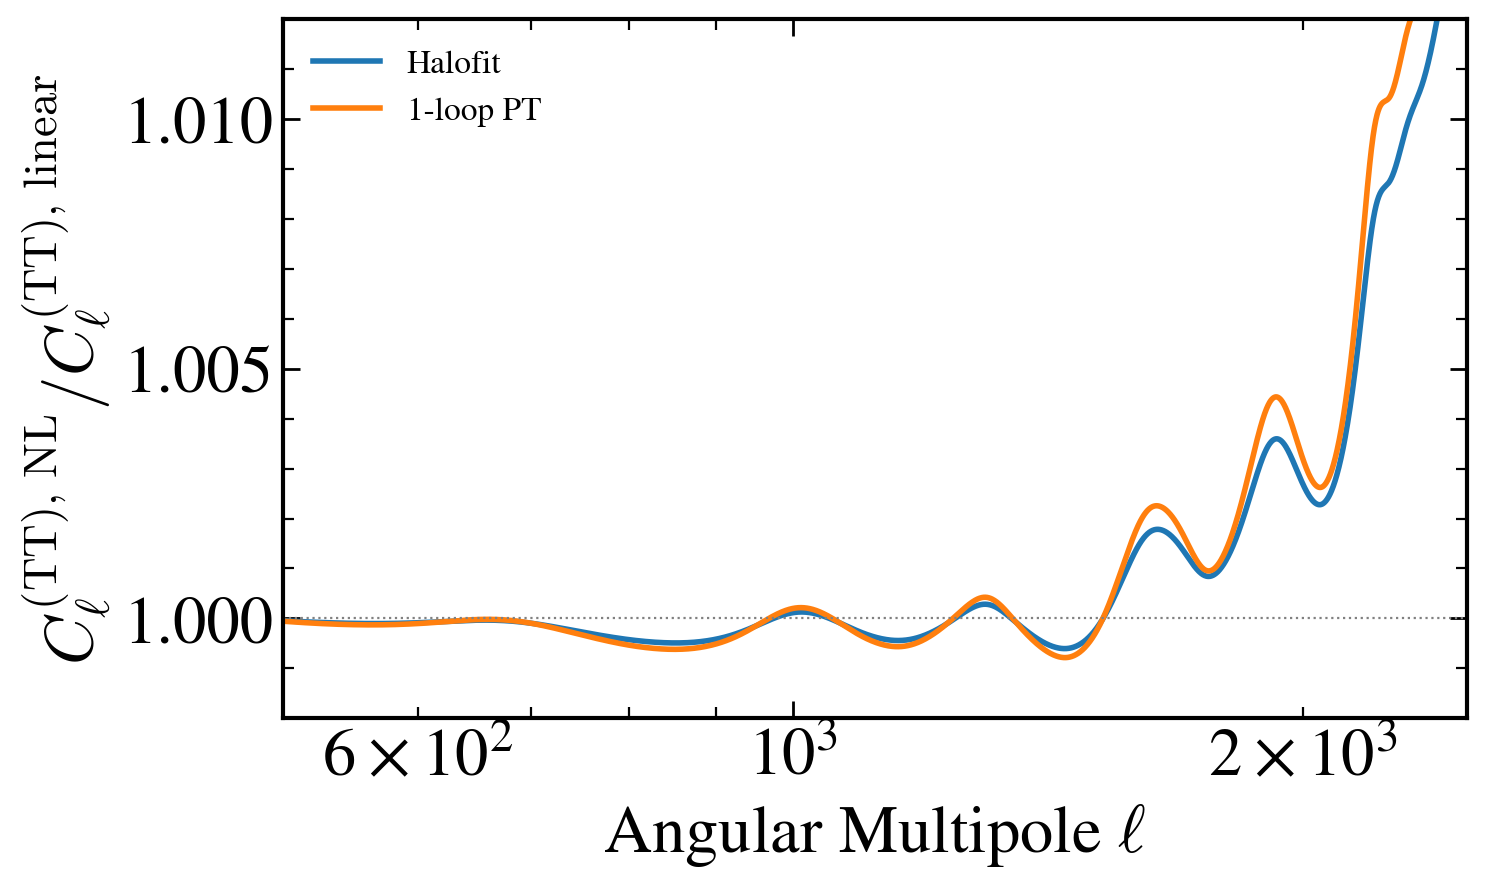

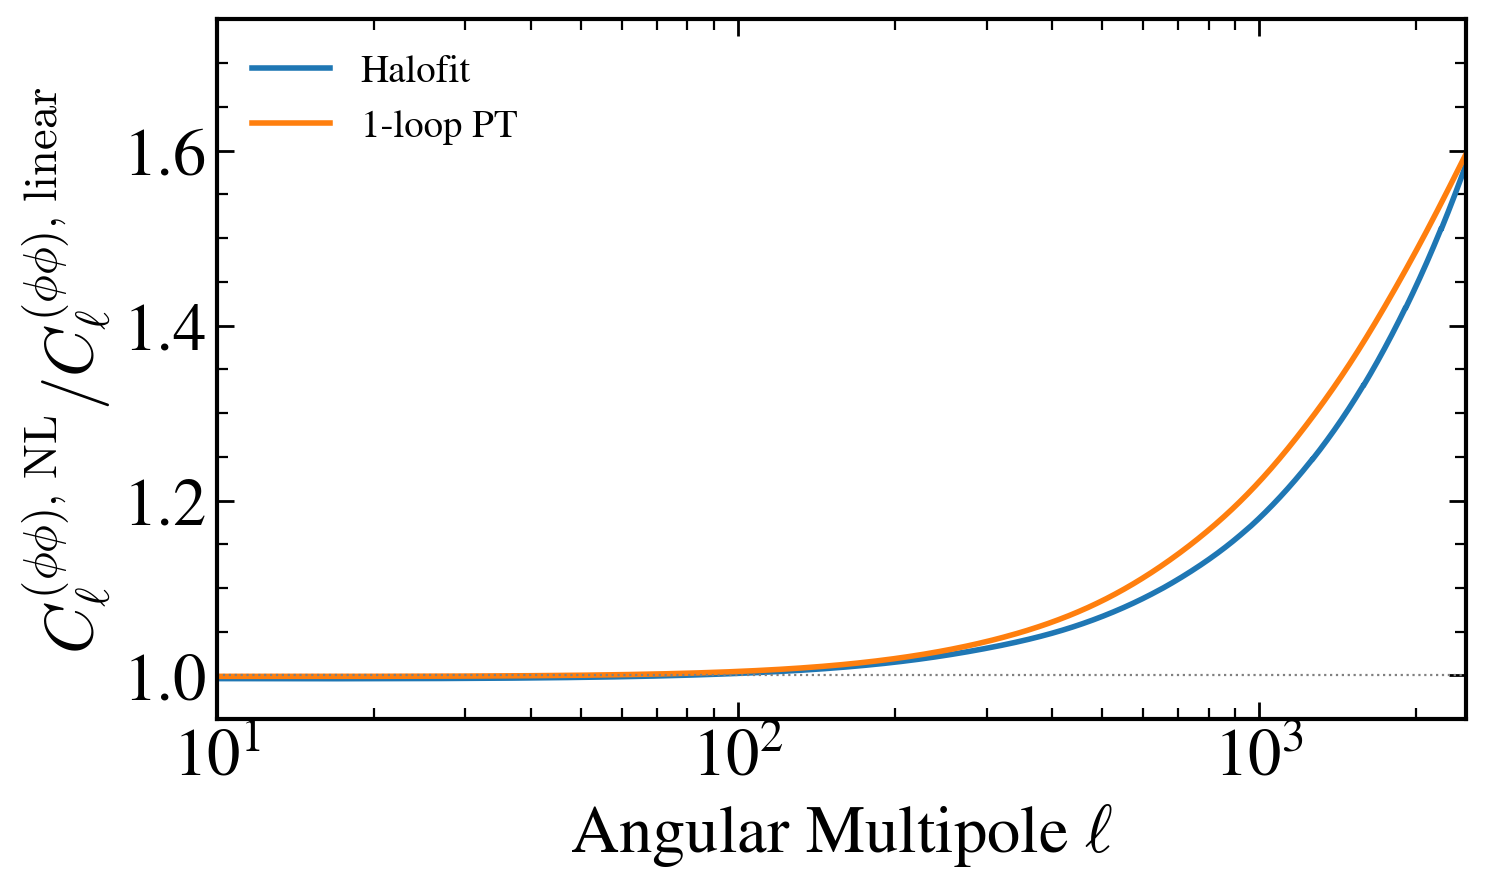

In [15]:
ll = np.arange(2, l_max + 1)

# --- Plot 8: Lensed TT NL/linear ratio ---
tt_lin = np.array(tt_lensed_lin)[2:]
tt_hf = np.array(tt_lensed_hf)[2:]
tt_1loop = np.array(tt_lensed_1loop)[2:]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(ll, tt_hf / tt_lin, color='C0', ls='-', lw=2, label='Halofit')
ax.semilogx(ll, tt_1loop / tt_lin, color='C1', ls='-', lw=2, label='1-loop PT')
ax.set_xlim(500, 2500)
ax.set_ylim(0.998, 1.012)
ax.set_xlabel(r'Angular Multipole $\ell$')
ax.set_ylabel(r'$C_\ell^{\mathrm{(TT),\,NL}} / C_\ell^{\mathrm{(TT),\,linear}}$')
ax.legend(fontsize=12, loc='upper left')
ax.axhline(1.0, color='gray', ls=':', lw=0.8)
fig.tight_layout()
fig.savefig('figures/ratios-cltt.pdf')

# --- Plot 9: C_l^pp NL/linear ratio ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(ll, ratio_hf, color='C0', ls='-', lw=2, label='Halofit')
ax.semilogx(ll, ratio_1loop, color='C1', ls='-', lw=2, label='1-loop PT')
ax.set_xlim(10, 2500)
ax.set_ylim(0.95, 1.75)
ax.set_xlabel(r'Angular Multipole $\ell$')
ax.set_ylabel(r'$C_\ell^{(\phi\phi),\,\mathrm{NL}} / C_\ell^{(\phi\phi),\,\mathrm{linear}}$')
ax.legend(fontsize=14, loc='upper left')
ax.axhline(1.0, color='gray', ls=':', lw=0.8)
fig.tight_layout()
fig.savefig('figures/ratios-clpp.pdf')